Project 4: Unsupervised Image Clustering and Visualization
Name Ayleen Santander

Part 1: Data Preparation and Exploration

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from PIL import Image
import os
import json
import joblib
import plotly.express as px
from sklearn.manifold import TSNE, trustworthiness
from sklearn.metrics import silhouette_samples
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.ndimage import center_of_mass, shift
from scipy.ndimage import zoom
from sklearn.metrics import confusion_matrix
from sklearn.datasets import fetch_openml, load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                             normalized_mutual_info_score)

sns.set_theme(style="whitegrid")
np.random.seed(42)

1. Load and preprocess the MNIST dataset, normalizing the images and flattening them into vectors suitable for analysis.
(fetch_openml pulls MNIST through Scikit-learn (no manual download). The first run takes a minute; after that it loads from the local cache.)

In [2]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")

X_raw = mnist.data          # pixel values 0-255
y = mnist.target.astype(int)  # labels come as strings -> convert to int

print("X shape:", X_raw.shape)
print("y shape:", y.shape)
print("X dtype:", X_raw.dtype, "| min:", X_raw.min(), "| max:", X_raw.max())

X shape: (70000, 784)
y shape: (70000,)
X dtype: int64 | min: 0 | max: 255


2. Preprocessing
   (Confirm there are no missing values and that pixel values sit in the expected 0-255 range.)

In [3]:
print("Missing values in X:", np.isnan(X_raw).sum())
print("Missing values in y:", pd.isna(y).sum())

assert X_raw.shape == (70000, 784), f"Unexpected shape: {X_raw.shape}"
assert X_raw.min() >= 0 and X_raw.max() <= 255, "Pixel values outside 0-255"
print("Data quality checks passed.")

Missing values in X: 0
Missing values in y: 0
Data quality checks passed.


3. Normalize
(Divide by 255 so every pixel is between 0 and 1. This keeps features on the same scale, which helps most ML algorithms train faster and more reliably.)

In [4]:
X = (X_raw / 255.0).astype(np.float32)
print("After normalization -> min:", X.min(), "| max:", X.max(), "| dtype:", X.dtype)

After normalization -> min: 0.0 | max: 1.0 | dtype: float32


4. Flatten
(Each image is 28x28 pixels. fetch_openml already returns them flattened into 784-length vectors. The cell below shows the round trip between the image form and the vector form.)

In [5]:
images = X.reshape(-1, 28, 28)   # image form (for plotting)
X_flat = images.reshape(len(images), -1)  # vector form (for analysis)

print("Image form: ", images.shape)
print("Vector form:", X_flat.shape)
assert np.array_equal(X_flat, X), "Flattening changed the data"
X = X_flat

Image form:  (70000, 28, 28)
Vector form: (70000, 784)


5.Train / test split
(MNIST has a standard split: the first 60,000 images are for training and the last 10,000 for testing.)

In [6]:
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print("Train:", X_train.shape, y_train.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (60000, 784) (60000,)
Test:  (10000, 784) (10000,)


6. Exploratory Data Analysis (EDA) - Class Distribution

,train_count,train_pct,test_count,test_pct
digit,,,,
0,5923,9.87,980,9.80
1,6742,11.24,1135,11.35
2,5958,9.93,1032,10.32
3,6131,10.22,1010,10.10
4,5842,9.74,982,9.82
5,5421,9.04,892,8.92
6,5918,9.86,958,9.58
7,6265,10.44,1028,10.28
8,5851,9.75,974,9.74


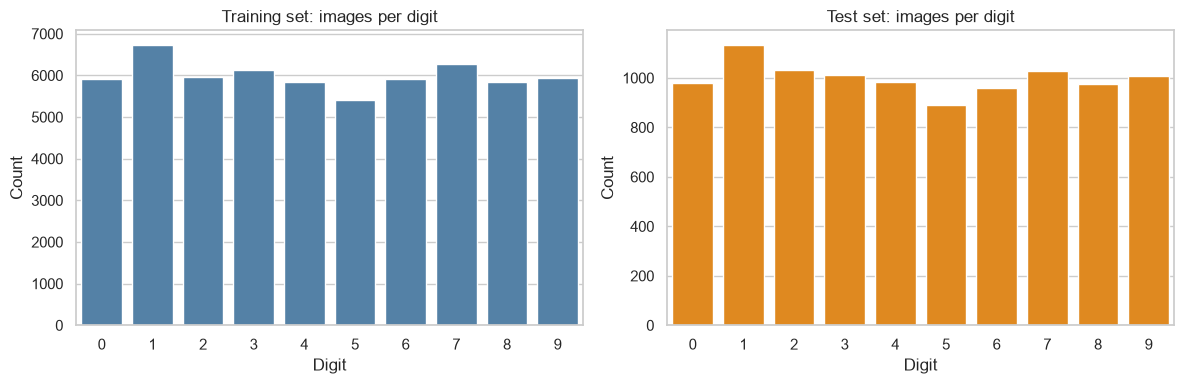

In [7]:
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

dist = pd.DataFrame({
    "train_count": train_counts,
    "train_pct": (train_counts / len(y_train) * 100).round(2),
    "test_count": test_counts,
    "test_pct": (test_counts / len(y_test) * 100).round(2),
})
dist.index.name = "digit"
display(dist)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=train_counts.index, y=train_counts.values, ax=axes[0], color="steelblue")
axes[0].set_title("Training set: images per digit")
sns.barplot(x=test_counts.index, y=test_counts.values, ax=axes[1], color="darkorange")
axes[1].set_title("Test set: images per digit")
for ax in axes:
    ax.set_xlabel("Digit"); ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=120)
plt.show()

Note: The classes are roughly balanced (each digit is about 9-11% of the data). Digit 1 is the most common and 5 the least common, but the gap is small, so no rebalancing is needed.

7. Sample images

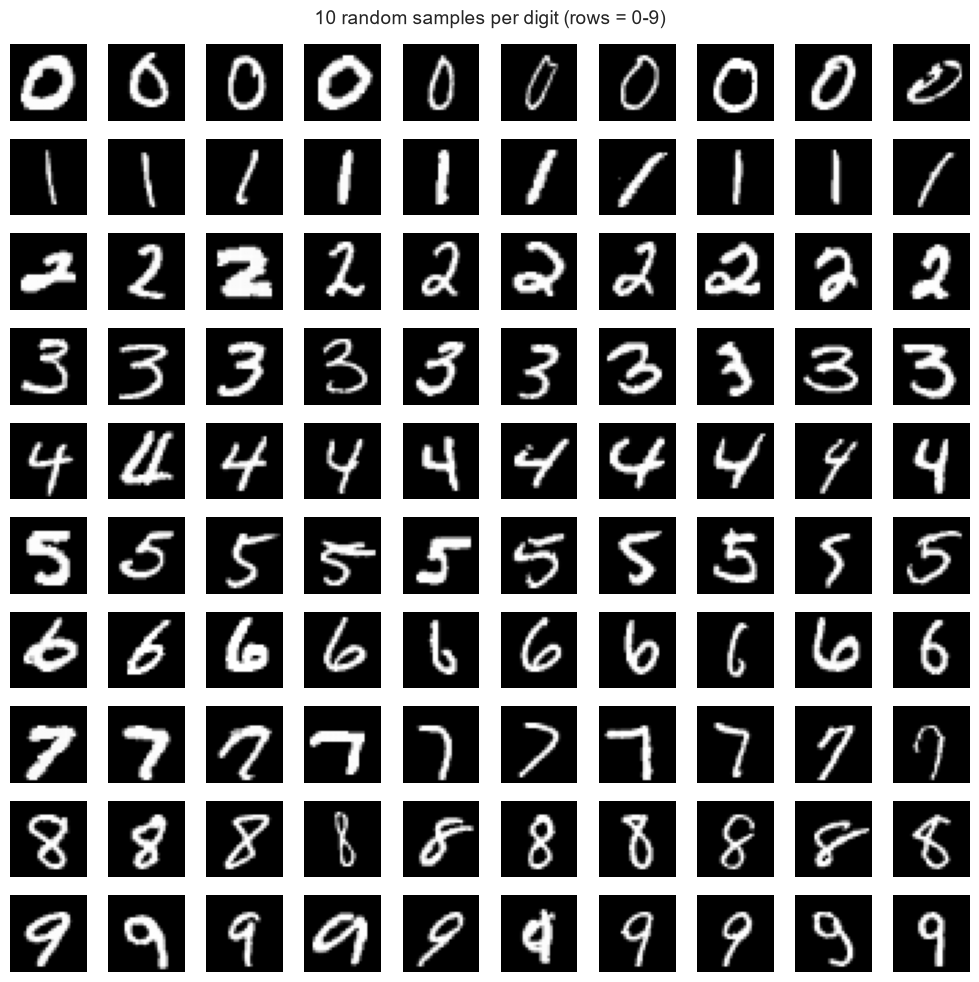

In [8]:
fig, axes = plt.subplots(10, 10, figsize=(10, 10))
for digit in range(10):
    idx = np.random.choice(np.where(y_train == digit)[0], 10, replace=False)
    for j, i in enumerate(idx):
        ax = axes[digit, j]
        ax.imshow(X_train[i].reshape(28, 28), cmap="gray")
        ax.axis("off")
plt.suptitle("10 random samples per digit (rows = 0-9)", fontsize=14)
plt.tight_layout()
plt.savefig("sample_images.png", dpi=120)
plt.show()

Note: Handwriting varies a lot within each digit (slant, thickness, size), which is what makes this a meaningful classification problem.

8.  Average image per digit

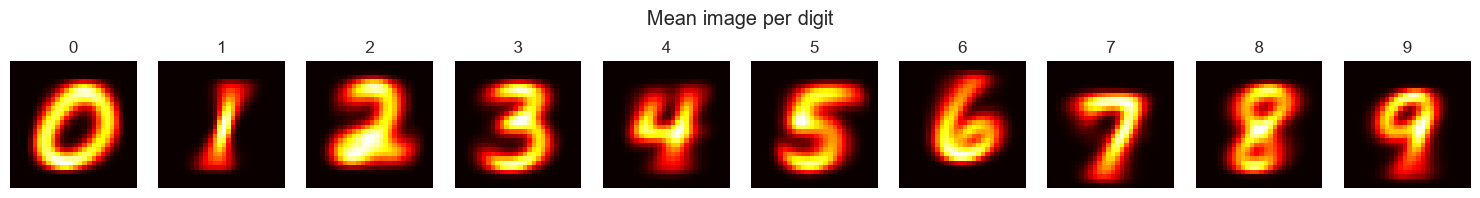

In [9]:
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for digit in range(10):
    mean_img = X_train[y_train == digit].mean(axis=0).reshape(28, 28)
    axes[digit].imshow(mean_img, cmap="hot")
    axes[digit].set_title(str(digit))
    axes[digit].axis("off")
plt.suptitle("Mean image per digit")
plt.tight_layout()
plt.savefig("mean_images.png", dpi=120)
plt.show()

Note:  The averages are clearly recognizable, so each digit has a consistent overall shape. Blurrier averages (like 4, 5, 8) suggest more variation in how people write them.

9. Pixel intensity distribution

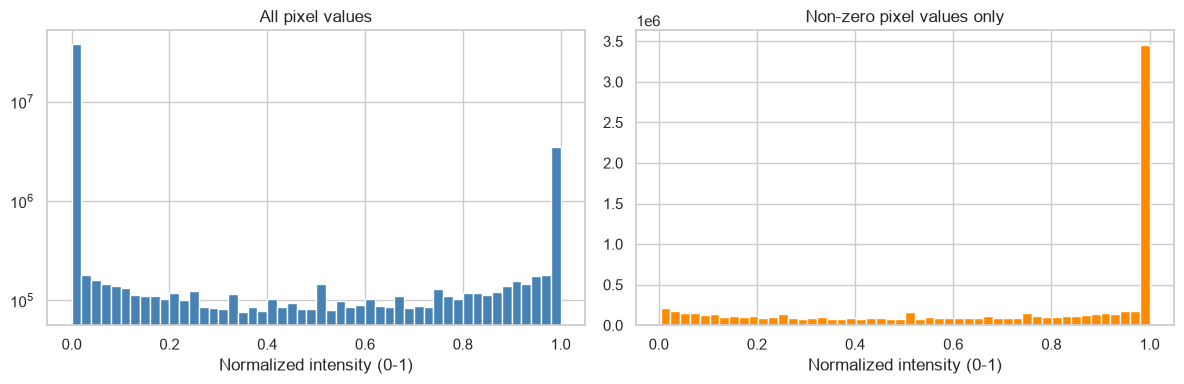

Share of pixels that are exactly 0: 80.9%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_train.ravel(), bins=50, color="steelblue")
axes[0].set_title("All pixel values")
axes[0].set_yscale("log")
axes[0].set_xlabel("Normalized intensity (0-1)")

nonzero = X_train[X_train > 0]
axes[1].hist(nonzero, bins=50, color="darkorange")
axes[1].set_title("Non-zero pixel values only")
axes[1].set_xlabel("Normalized intensity (0-1)")
plt.tight_layout()
plt.savefig("pixel_distribution.png", dpi=120)
plt.show()

print(f"Share of pixels that are exactly 0: {(X_train == 0).mean():.1%}")

Note: Most pixels are background (value 0), roughly 80%. Among the 'ink' pixels, values cluster near 1 (fully white strokes), with a smaller spread of mid-tones along stroke edges.

10. Which pixels carry information?

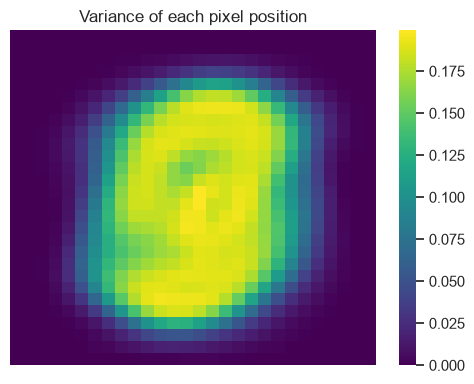

Pixels that are 0 in every training image: 67 of 784


In [11]:
pixel_var = X_train.var(axis=0).reshape(28, 28)
always_zero = (X_train.max(axis=0) == 0).sum()

plt.figure(figsize=(5, 4))
sns.heatmap(pixel_var, cmap="viridis", xticklabels=False, yticklabels=False)
plt.title("Variance of each pixel position")
plt.tight_layout()
plt.savefig("pixel_variance.png", dpi=120)
plt.show()

print(f"Pixels that are 0 in every training image: {always_zero} of 784")

11. EEDA -Ink per digit

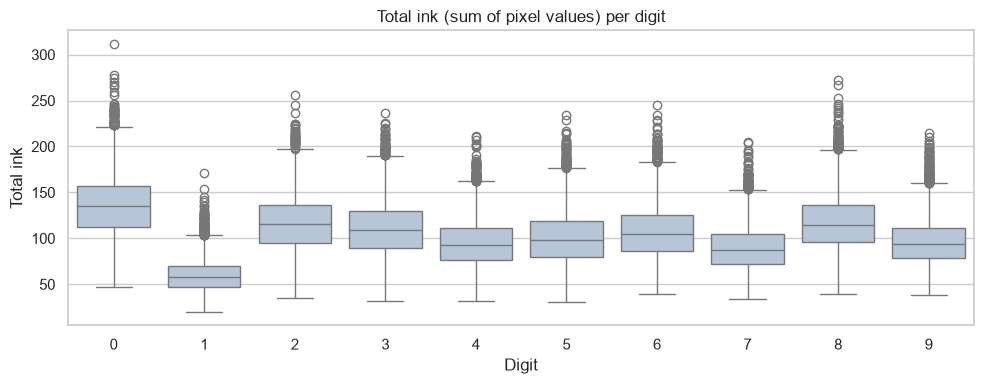

,count,mean,std,min,25%,50%,75%,max
digit,,,,,,,,
0,5923.0,135.9,33.0,47.0,112.6,134.7,156.5,311.7
1,6742.0,59.6,17.2,19.9,47.2,57.4,69.7,171.3
2,5958.0,116.8,29.8,35.4,95.4,115.3,136.2,255.6
3,6131.0,111.0,29.6,31.5,89.9,108.9,129.8,236.5
4,5842.0,95.2,25.0,32.3,76.8,92.5,110.9,211.1
5,5421.0,100.9,29.2,31.0,80.0,98.3,118.7,234.5
6,5918.0,107.6,29.3,39.3,86.7,104.8,125.3,245.1
7,6265.0,89.8,24.0,33.9,72.4,87.4,104.6,205.3
8,5851.0,117.7,30.3,39.8,95.9,115.0,136.3,272.7


In [12]:
ink = pd.DataFrame({"digit": y_train, "ink": X_train.sum(axis=1)})

plt.figure(figsize=(10, 4))
sns.boxplot(data=ink, x="digit", y="ink", color="lightsteelblue")
plt.title("Total ink (sum of pixel values) per digit")
plt.xlabel("Digit")
plt.ylabel("Total ink")
plt.tight_layout()
plt.savefig("ink_per_digit.png", dpi=120)
plt.show()

display(ink.groupby("digit")["ink"].describe().round(1))


Note: Digit 1 uses the least ink and 0 and 8 use the most. Ink alone can't separate all digits, but it's a simple feature that already carries some signal.

12. EDA - Dimensionality check with PCA (PCA explained variance)

80% of variance kept with 44 components
90% of variance kept with 87 components
95% of variance kept with 154 components
99% of variance kept with 331 components


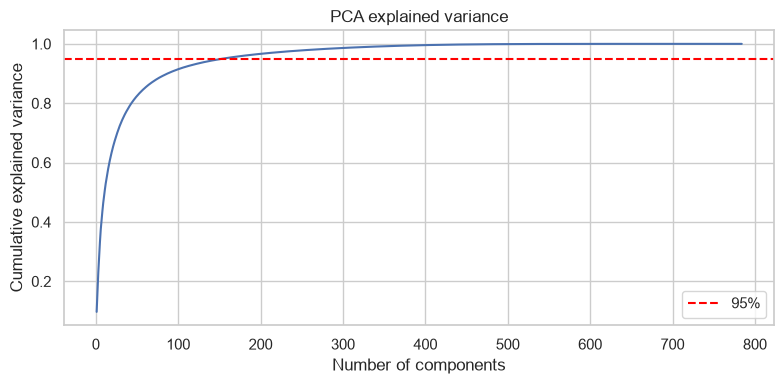

In [13]:
pca_full = PCA().fit(X_train)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

for target in [0.80, 0.90, 0.95, 0.99]:
    n = np.argmax(cum_var >= target) + 1
    print(f"{int(target*100)}% of variance kept with {n} components")

plt.figure(figsize=(8, 4))
plt.plot(range(1, 785), cum_var)
plt.axhline(0.95, color="red", linestyle="--", label="95%")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance")
plt.legend()
plt.tight_layout()
plt.savefig("pca_variance.png", dpi=120)
plt.show()

13. EDA - PCA 2D projection (5,000 -image sample)

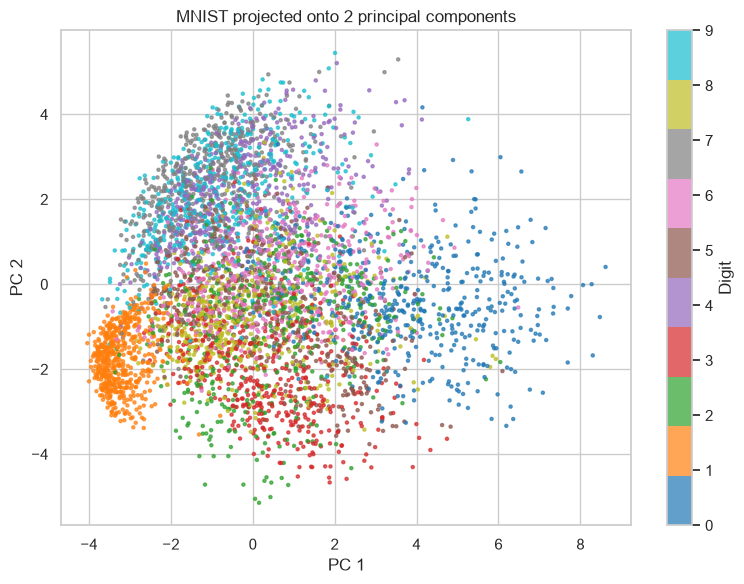

In [14]:
idx = np.random.choice(len(X_train), 5000, replace=False)
X_2d = PCA(n_components=2).fit_transform(X_train[idx])

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train[idx], cmap="tab10", s=5, alpha=0.7)
plt.colorbar(sc, ticks=range(10), label="Digit")
plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.title("MNIST projected onto 2 principal components")
plt.tight_layout()
plt.savefig("pca_2d.png", dpi=120)
plt.show()

Note: About 150 components keep 95% of the variance, so the 784 pixels are highly redundant. In 2D, some digits (like 0 and 1) form distinct clusters while others overlap heavily, which shows a linear 2D view isn't enough to separate every class.

14. Optional: Scikit-learn's built-in digits dataset
(load_digits ships with Scikit-learn itself (no download at all). It's a smaller, lower-resolution version of the same idea: 1,797 images at 8x8 pixels.)

digits X shape: (1797, 64) | classes: [0 1 2 3 4 5 6 7 8 9]


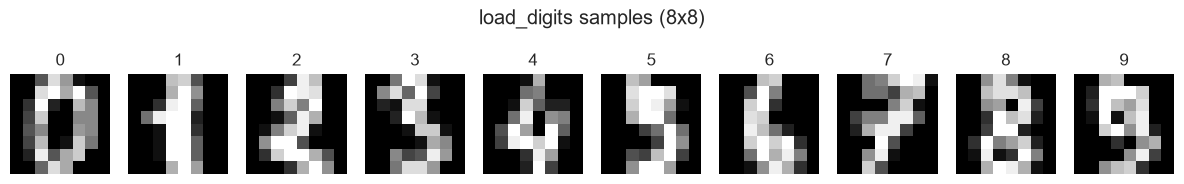

,MNIST,load_digits
Images,"70,000","1,797"
Resolution,28x28,8x8
Features,784,64
Raw pixel range,0-255,0-16


In [15]:
digits = load_digits()
Xd = digits.data / 16.0   # pixel values are 0-16 here
yd = digits.target

print("digits X shape:", Xd.shape, "| classes:", np.unique(yd))

fig, axes = plt.subplots(1, 10, figsize=(12, 2))
for d in range(10):
    axes[d].imshow(Xd[yd == d][0].reshape(8, 8), cmap="gray")
    axes[d].set_title(str(d)); axes[d].axis("off")
plt.suptitle("load_digits samples (8x8)")
plt.tight_layout()
plt.savefig("digits_samples.png", dpi=120)
plt.show()

comparison = pd.DataFrame({
    "MNIST": ["70,000", "28x28", 784, "0-255"],
    "load_digits": ["1,797", "8x8", 64, "0-16"],
}, index=["Images", "Resolution", "Features", "Raw pixel range"])
display(comparison)

Summary of findings
Size: 70,000 grayscale images (60,000 train / 10,000 test), each flattened to 784 features.
Quality: No missing values; pixels were normalized from 0-255 to 0-1.
Balance: All 10 digits are roughly equally represented, so accuracy is a fair metric and no resampling is needed.
Sparsity: About 80% of pixels are background, and border pixels carry almost no information.
Redundancy: PCA keeps 95% of the variance with about 150 of 784 components, so dimensionality reduction is a sensible next step.
Separability: Some digits separate easily (0, 1) while others overlap (4/9, 3/5/8), which points to where a classifier is most likely to make mistakes.

Part 2: Clustering
1. Apply the K-Means clustering algorithm to identify groups within the dataset.
2. Determine the optimal number of clusters using techniques like the elbow method.
3. Analyze cluster centroids to interpret the characteristics of each group.

1. Sample for the elbow search (speed)

In [16]:
# Running K-Means 14 times on 60,000 x 784 is slow, so we
# search for k on a 10,000-image random sample.
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_train), 10000, replace=False)
X_sample = X_train[sample_idx]
y_sample = y_train[sample_idx]
print("Sample shape:", X_sample.shape)

Sample shape: (10000, 784)


In [19]:
# Elbow method + silhouette score
k_values = range(2, 16)
inertias, silhouettes = [], []

# Silhouette is expensive, so score it on a smaller subset
sil_idx = rng.choice(len(X_sample), 3000, replace=False)

for k in k_values:
    start = time.time()
    km = KMeans(n_clusters=k, n_init=5, random_state=42)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sample[sil_idx], labels[sil_idx]))
    print(f"k={k:2d} | inertia={km.inertia_:,.0f} | "
          f"silhouette={silhouettes[-1]:.4f} | {time.time()-start:.1f}s")

k= 2 | inertia=492,067 | silhouette=0.0843 | 1.6s
k= 3 | inertia=467,921 | silhouette=0.0540 | 1.7s
k= 4 | inertia=449,889 | silhouette=0.0594 | 1.9s
k= 5 | inertia=433,156 | silhouette=0.0661 | 2.1s
k= 6 | inertia=421,523 | silhouette=0.0618 | 3.0s
k= 7 | inertia=412,584 | silhouette=0.0644 | 3.7s
k= 8 | inertia=404,523 | silhouette=0.0692 | 3.3s
k= 9 | inertia=397,409 | silhouette=0.0546 | 3.5s
k=10 | inertia=391,672 | silhouette=0.0568 | 3.8s
k=11 | inertia=386,078 | silhouette=0.0575 | 4.7s
k=12 | inertia=380,550 | silhouette=0.0566 | 5.0s
k=13 | inertia=375,221 | silhouette=0.0599 | 5.6s
k=14 | inertia=370,880 | silhouette=0.0618 | 5.4s
k=15 | inertia=366,818 | silhouette=0.0601 | 5.3s


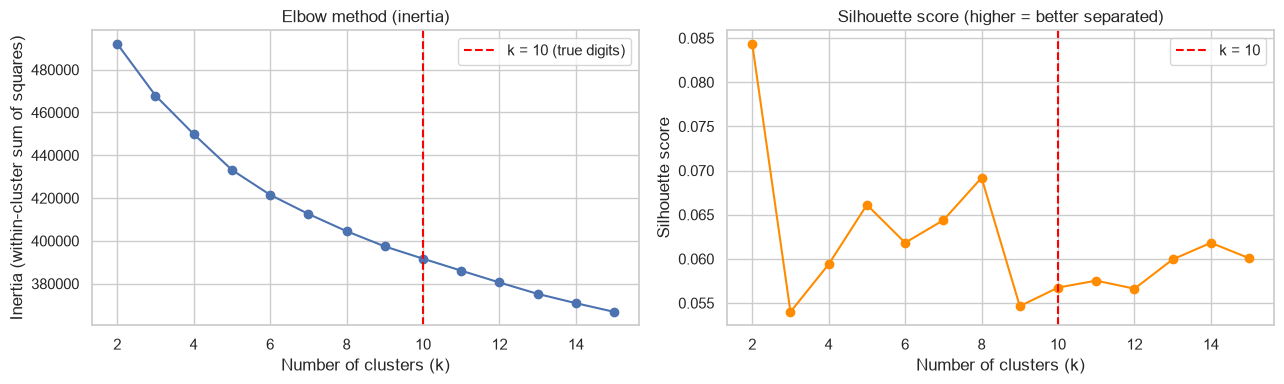

In [20]:
#Visual / Plot elbow and silhouette curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_values, inertias, marker="o")
axes[0].axvline(10, color="red", linestyle="--", label="k = 10 (true digits)")
axes[0].set_title("Elbow method (inertia)")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster sum of squares)")
axes[0].legend()

axes[1].plot(k_values, silhouettes, marker="o", color="darkorange")
axes[1].axvline(10, color="red", linestyle="--", label="k = 10")
axes[1].set_title("Silhouette score (higher = better separated)")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].legend()

plt.tight_layout()
plt.savefig("elbow_silhouette.png", dpi=120)
plt.show()

In [21]:
#Rate of improvement (helps spot the elbow)
elbow_df = pd.DataFrame({"k": list(k_values), "inertia": inertias,
                         "silhouette": silhouettes})
elbow_df["pct_drop"] = (-elbow_df["inertia"].pct_change() * 100).round(2)
display(elbow_df)

,k,inertia,silhouette,pct_drop
0,2,492067.21875,0.084344,NaN
1,3,467920.59375,0.054002,4.91
2,4,449889.46875,0.059391,3.85
3,5,433156.18750,0.066126,3.72
4,6,421522.90625,0.061830,2.69
5,7,412583.56250,0.064377,2.12
6,8,404522.53125,0.069180,1.95
7,9,397408.68750,0.054647,1.76
8,10,391671.84375,0.056751,1.44
9,11,386078.12500,0.057540,1.43


In [22]:
#Fit the final K-Means model (k = 10) on full training set
K = 10
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
start = time.time()
train_clusters = kmeans.fit_predict(X_train)
print(f"Fitted in {time.time()-start:.1f}s | inertia = {kmeans.inertia_:,.0f}")

test_clusters = kmeans.predict(X_test)

cluster_sizes = pd.Series(train_clusters).value_counts().sort_index()
print("\nImages per cluster:")
print(cluster_sizes)


Fitted in 45.5s | inertia = 2,352,828

Images per cluster:
0    8839
1    5960
2    3098
3    5714
4    3198
5    8929
6    6514
7    4675
8    7435
9    5638
Name: count, dtype: int64


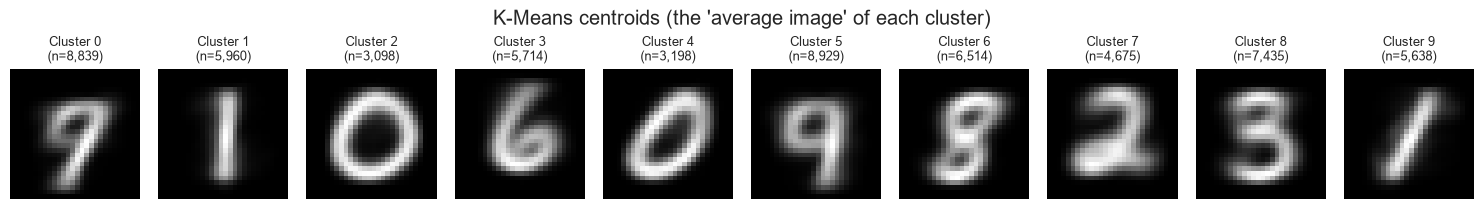

In [23]:
#Visualize the cluster centroids
centroids = kmeans.cluster_centers_          # shape (10, 784)
assert centroids.shape == (K, 784), f"Unexpected centroid shape: {centroids.shape}"

fig, axes = plt.subplots(1, K, figsize=(15, 2.2))
for c in range(K):
    axes[c].imshow(centroids[c].reshape(28, 28), cmap="gray")
    axes[c].set_title(f"Cluster {c}\n(n={cluster_sizes[c]:,})", fontsize=9)
    axes[c].axis("off")
plt.suptitle("K-Means centroids (the 'average image' of each cluster)")
plt.tight_layout()
plt.savefig("kmeans_centroids.png", dpi=120)
plt.show()

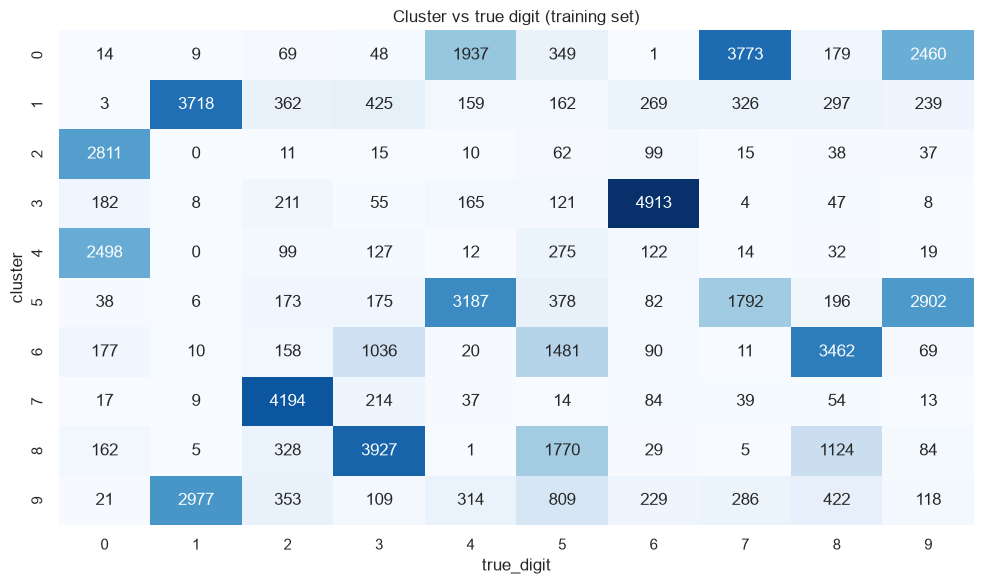

In [24]:
#Which true digits fall in each cluster?
ct = pd.crosstab(pd.Series(train_clusters, name="cluster"),
                 pd.Series(y_train, name="true_digit"))

plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Cluster vs true digit (training set)")
plt.tight_layout()
plt.savefig("cluster_vs_digit.png", dpi=120)
plt.show()

In [25]:
#Cluster profile table (interpret each group)
profile = pd.DataFrame({
    "size": ct.sum(axis=1),
    "majority_digit": ct.idxmax(axis=1),
    "purity_pct": (ct.max(axis=1) / ct.sum(axis=1) * 100).round(1),
    "second_digit": ct.apply(lambda r: r.nlargest(2).index[1], axis=1),
    "second_pct": ct.apply(lambda r: r.nlargest(2).iloc[1] / r.sum() * 100,
                           axis=1).round(1),
    "avg_ink": [X_train[train_clusters == c].sum(axis=1).mean().round(1)
                for c in range(K)],
})
display(profile.sort_values("majority_digit"))

missing_digits = set(range(10)) - set(profile["majority_digit"])
print("Digits with no cluster of their own:", sorted(missing_digits) or "none")

,size,majority_digit,purity_pct,second_digit,second_pct,avg_ink
cluster,,,,,,
2,3098,0,90.7,6,3.2,139.399994
4,3198,0,78.1,5,8.6,139.500000
1,5960,1,62.4,3,7.1,61.000000
9,5638,1,52.8,5,14.3,71.599998
7,4675,2,89.7,3,4.6,124.300003
8,7435,3,52.8,5,23.8,114.699997
5,8929,4,35.7,9,32.5,95.099998
3,5714,6,86.0,2,3.7,109.900002
0,8839,7,42.7,9,27.8,94.099998


Digits with no cluster of their own: [5, 9]


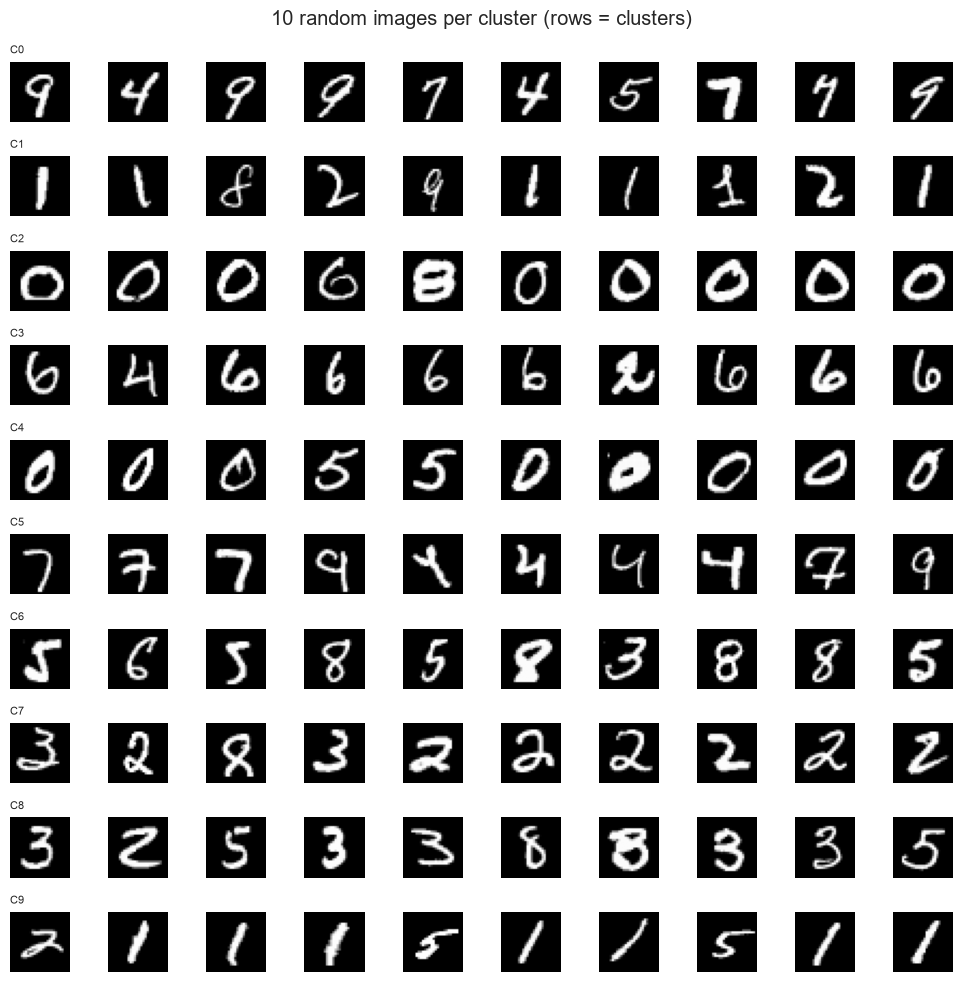

In [26]:
#Sample images from each cluster
fig, axes = plt.subplots(K, 10, figsize=(10, 10))
for c in range(K):
    members = np.where(train_clusters == c)[0]
    picks = rng.choice(members, 10, replace=False)
    for j, i in enumerate(picks):
        axes[c, j].imshow(X_train[i].reshape(28, 28), cmap="gray")
        axes[c, j].axis("off")
    axes[c, 0].set_title(f"C{c}", fontsize=8, loc="left")
plt.suptitle("10 random images per cluster (rows = clusters)")
plt.tight_layout()
plt.savefig("cluster_samples.png", dpi=120)
plt.show()


In [27]:
#How well do clusters match real digits?
# Map each cluster to its majority digit, then score like a classifier
cluster_to_digit = profile["majority_digit"].to_dict()

train_pred = pd.Series(train_clusters).map(cluster_to_digit).values
test_pred = pd.Series(test_clusters).map(cluster_to_digit).values

print(f"Train accuracy (majority mapping): {(train_pred == y_train).mean():.1%}")
print(f"Test accuracy  (majority mapping): {(test_pred == y_test).mean():.1%}")
print(f"Adjusted Rand Index (test):        {adjusted_rand_score(y_test, test_clusters):.3f}")
print(f"Normalized Mutual Info (test):     {normalized_mutual_info_score(y_test, test_clusters):.3f}")

Train accuracy (majority mapping): 59.1%
Test accuracy  (majority mapping): 59.5%
Adjusted Rand Index (test):        0.367
Normalized Mutual Info (test):     0.498


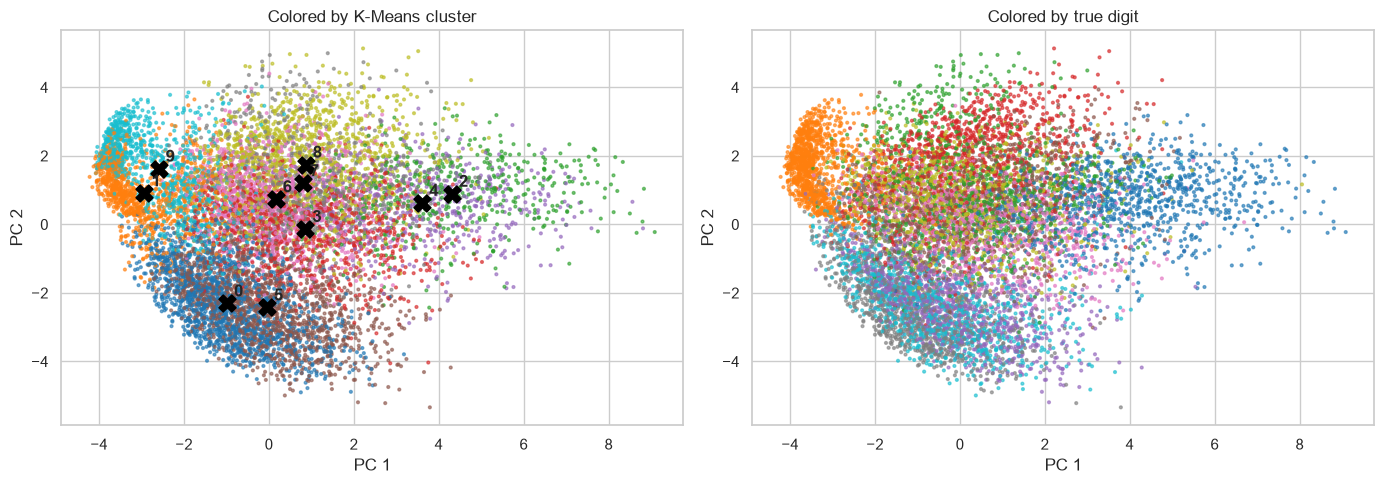

In [28]:
#Clusters in 2D (PCA view) with centroids
pca2 = PCA(n_components=2).fit(X_train)
X_2d = pca2.transform(X_sample)
sample_clusters = kmeans.predict(X_sample)
cent_2d = pca2.transform(centroids)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=sample_clusters, cmap="tab10", s=4, alpha=0.6)
axes[0].scatter(cent_2d[:, 0], cent_2d[:, 1], c="black", marker="X", s=150)
for c, (x0, y0) in enumerate(cent_2d):
    axes[0].annotate(str(c), (x0, y0), fontsize=12, fontweight="bold",
                     xytext=(5, 5), textcoords="offset points")
axes[0].set_title("Colored by K-Means cluster")

axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y_sample, cmap="tab10", s=4, alpha=0.6)
axes[1].set_title("Colored by true digit")

for ax in axes:
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
plt.tight_layout()
plt.savefig("clusters_pca_2d.png", dpi=120)
plt.show()

Part 3: Model Evaluation and Prediction
1. Demonstrate how to use the trained K-Means model to assign cluster labels to new image data instances. 
2. Validate the model by predicting cluster assignments for a separate set of images and analyzing their fit with existing clusters. 

In [30]:
#Preprocessing function for NEW images
# New data must go through the exact same steps as the training data:
# pixels scaled to 0-1 and each image flattened to 784 values.
def preprocess_images(images):
    arr = np.asarray(images, dtype=np.float32)

    if arr.ndim == 1:                        # one flattened image (784,)
        arr = arr[None, :]
    elif arr.shape == (28, 28):              # one 28x28 image
        arr = arr.reshape(1, 784)
    elif arr.ndim == 3:                      # batch of 28x28 images
        arr = arr.reshape(len(arr), -1)

    assert arr.shape[1] == 784, f"Expected 784 pixels per image, got {arr.shape[1]}"

    if arr.max() > 1.0:                      # raw 0-255 input -> normalize
        arr = arr / 255.0
    return arr


In [31]:
#Prediction function
# Returns the cluster, the digit that cluster mostly represents,
# the distance to the nearest centroid, and a confidence margin
# (0 = equally close to two centroids, 1 = clearly closest to one).
def predict_cluster(images):
    X_new = preprocess_images(images)
    dists = kmeans.transform(X_new)          # distance to every centroid
    sorted_d = np.sort(dists, axis=1)

    clusters = dists.argmin(axis=1)
    return pd.DataFrame({
        "cluster": clusters,
        "predicted_digit": [cluster_to_digit[c] for c in clusters],
        "distance": sorted_d[:, 0].round(3),
        "margin": ((sorted_d[:, 1] - sorted_d[:, 0]) / sorted_d[:, 1]).round(3),
        "runner_up_cluster": np.argsort(dists, axis=1)[:, 1],
    })



In [32]:
#Define what a "good fit" looks like (from training data)
# For each cluster, the 95th percentile distance of its training images
# is the cut-off. New images beyond it don't fit their cluster well.
train_dist = kmeans.transform(X_train).min(axis=1)

fit_threshold = (pd.DataFrame({"cluster": train_clusters, "dist": train_dist})
                 .groupby("cluster")["dist"].quantile(0.95))
print("95th percentile distance per cluster (training):")
print(fit_threshold.round(3))

def add_fit_flag(results):
    results = results.copy()
    results["threshold"] = results["cluster"].map(fit_threshold).round(3)
    results["good_fit"] = results["distance"] <= results["threshold"]
    return results


95th percentile distance per cluster (training):
cluster
0    7.385
1    6.677
2    8.347
3    8.108
4    7.906
5    8.061
6    7.658
7    8.254
8    8.137
9    7.073
Name: dist, dtype: float64


,cluster,predicted_digit,distance,margin,runner_up_cluster,threshold,good_fit,true_digit
0,3,6,7.801,0.095,7,8.108,True,6
1,5,4,5.799,0.097,0,8.061,True,9
2,3,6,6.409,0.169,8,8.108,True,6
3,8,3,6.643,0.090,4,8.137,True,3
4,8,3,6.581,0.031,6,8.137,True,8
5,0,7,5.728,0.128,1,7.385,True,4
6,9,1,5.022,0.206,1,7.073,True,7
7,0,7,5.492,0.127,5,7.385,True,4


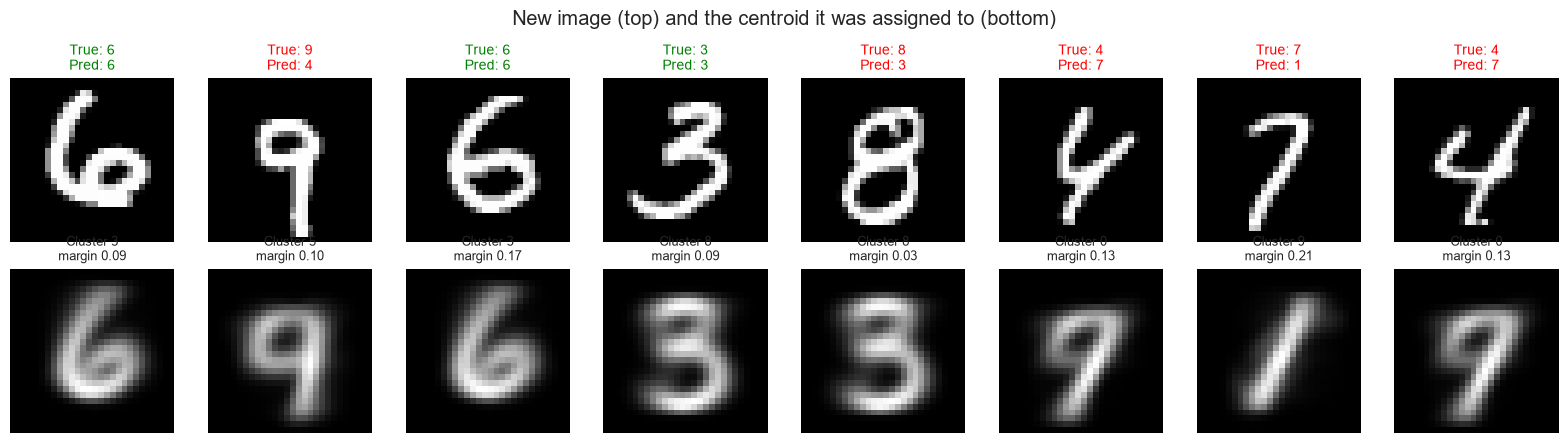

In [33]:
#Demo - assign clusters to a few new images
# Take raw 0-255 test images to prove the function handles preprocessing
demo_idx = rng.choice(len(X_test), 8, replace=False)
demo_raw = (X_test[demo_idx] * 255).reshape(-1, 28, 28)  # simulate raw new images

demo_results = add_fit_flag(predict_cluster(demo_raw))
demo_results["true_digit"] = y_test[demo_idx]
display(demo_results)

fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for j in range(8):
    r = demo_results.iloc[j]
    axes[0, j].imshow(demo_raw[j], cmap="gray")
    color = "green" if r.predicted_digit == r.true_digit else "red"
    axes[0, j].set_title(f"True: {r.true_digit}\nPred: {r.predicted_digit}",
                         color=color, fontsize=10)
    axes[1, j].imshow(kmeans.cluster_centers_[r.cluster].reshape(28, 28), cmap="gray")
    axes[1, j].set_title(f"Cluster {r.cluster}\nmargin {r.margin:.2f}", fontsize=9)
    for ax in axes[:, j]:
        ax.axis("off")
plt.suptitle("New image (top) and the centroid it was assigned to (bottom)")
plt.tight_layout()
plt.savefig("demo_predictions.png", dpi=120)
plt.show()



In [35]:
#Validation - full test set (10,000 unseen images)
test_results = add_fit_flag(predict_cluster(X_test))
test_results["true_digit"] = y_test

assert (test_results["cluster"].values == test_clusters).all(), \
    "predict_cluster disagrees with kmeans.predict"

print(f"Test accuracy (majority mapping): "
      f"{(test_results.predicted_digit == test_results.true_digit).mean():.1%}")
print(f"Test images with a good fit:      {test_results.good_fit.mean():.1%}  "
      f"(training reference = 95%)")
print(f"Mean distance - train: {train_dist.mean():.3f} | "
      f"test: {test_results.distance.mean():.3f}")

Test accuracy (majority mapping): 59.5%
Test images with a good fit:      95.2%  (training reference = 95%)
Mean distance - train: 6.161 | test: 6.163


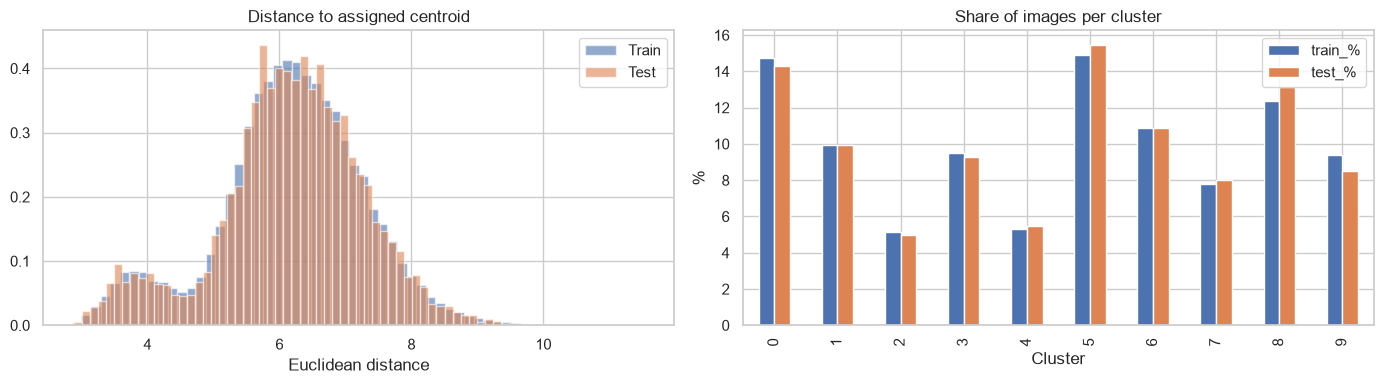

In [36]:
#Do test images fit the clusters like training images?
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_dist, bins=60, alpha=0.6, density=True, label="Train")
axes[0].hist(test_results.distance, bins=60, alpha=0.6, density=True, label="Test")
axes[0].set_title("Distance to assigned centroid")
axes[0].set_xlabel("Euclidean distance")
axes[0].legend()

size_compare = pd.DataFrame({
    "train_%": pd.Series(train_clusters).value_counts(normalize=True).sort_index() * 100,
    "test_%": test_results.cluster.value_counts(normalize=True).sort_index() * 100,
})
size_compare.plot(kind="bar", ax=axes[1])
axes[1].set_title("Share of images per cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("%")
plt.tight_layout()
plt.savefig("train_vs_test_fit.png", dpi=120)
plt.show()

In [37]:
#Per-cluster fit report (train vs test)
per_cluster = pd.DataFrame({
    "train_mean_dist": pd.Series(train_dist).groupby(train_clusters).mean(),
    "test_mean_dist": test_results.groupby("cluster")["distance"].mean(),
    "test_good_fit_%": test_results.groupby("cluster")["good_fit"].mean() * 100,
    "test_mean_margin": test_results.groupby("cluster")["margin"].mean(),
    "majority_digit": pd.Series(cluster_to_digit),
}).round(3)
per_cluster["dist_change_%"] = ((per_cluster.test_mean_dist / per_cluster.train_mean_dist - 1)
                                * 100).round(1)
display(per_cluster)


,train_mean_dist,test_mean_dist,test_good_fit_%,test_mean_margin,majority_digit,dist_change_%
0,5.911,5.930,95.095,0.130,7,0.3
1,4.699,4.626,95.281,0.235,1,-1.6
2,6.713,6.761,96.378,0.166,0,0.7
3,6.446,6.511,94.301,0.148,6,1.0
4,6.522,6.588,94.343,0.142,0,1.0
5,6.390,6.301,95.478,0.134,4,-1.4
6,6.483,6.515,94.761,0.094,8,0.5
7,7.001,6.962,95.250,0.120,2,-0.6
8,6.677,6.637,96.040,0.120,3,-0.6
9,5.194,5.166,95.193,0.187,1,-0.5


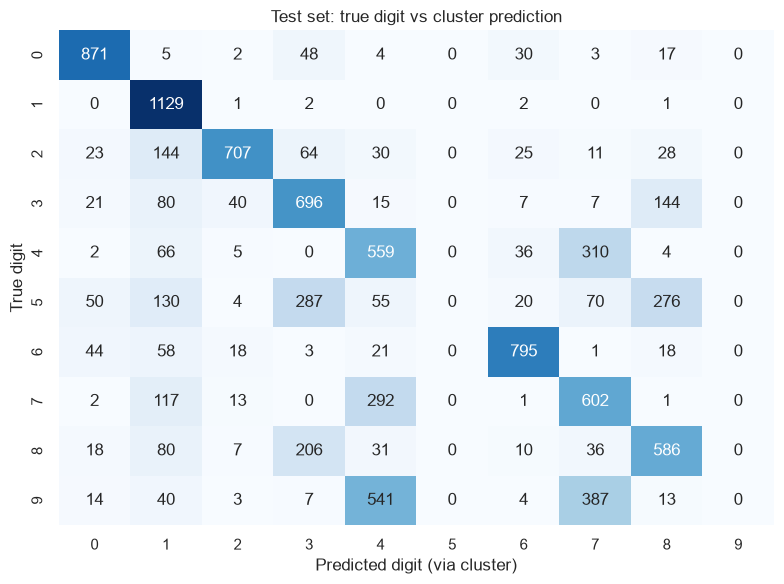

Accuracy per true digit (%):
true_digit
5     0.0
9     0.0
4    56.9
7    58.6
8    60.2
2    68.5
3    68.9
6    83.0
0    88.9
1    99.5
Name: correct, dtype: float64


In [38]:
#Confusion matrix and per-digit accuracy (test)
cm = confusion_matrix(test_results.true_digit, test_results.predicted_digit, labels=range(10))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted digit (via cluster)")
plt.ylabel("True digit")
plt.title("Test set: true digit vs cluster prediction")
plt.tight_layout()
plt.savefig("test_confusion.png", dpi=120)
plt.show()

per_digit = (test_results.assign(correct=test_results.predicted_digit == test_results.true_digit)
             .groupby("true_digit")["correct"].mean().mul(100).round(1))
print("Accuracy per true digit (%):")
print(per_digit.sort_values())

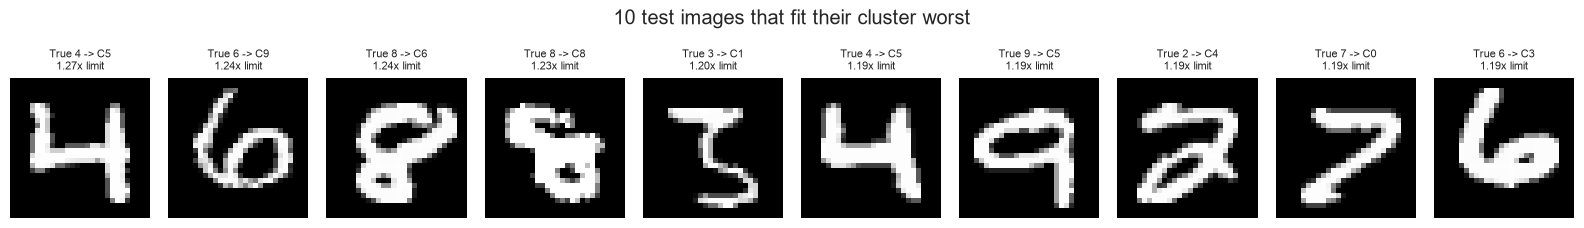

In [39]:
#Worst-fitting test images (possible outliers)
test_results["dist_ratio"] = test_results.distance / test_results.threshold
worst = test_results.nlargest(10, "dist_ratio")

fig, axes = plt.subplots(1, 10, figsize=(16, 2.5))
for ax, (i, r) in zip(axes, worst.iterrows()):
    ax.imshow(X_test[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"True {r.true_digit} -> C{r.cluster}\n{r.dist_ratio:.2f}x limit", fontsize=8)
    ax.axis("off")
plt.suptitle("10 test images that fit their cluster worst")
plt.tight_layout()
plt.savefig("worst_fit.png", dpi=120)
plt.show()

External set shape: (1797, 28, 28)
External accuracy:      33.6%
External good fit:      100.0%
External mean distance: 5.028


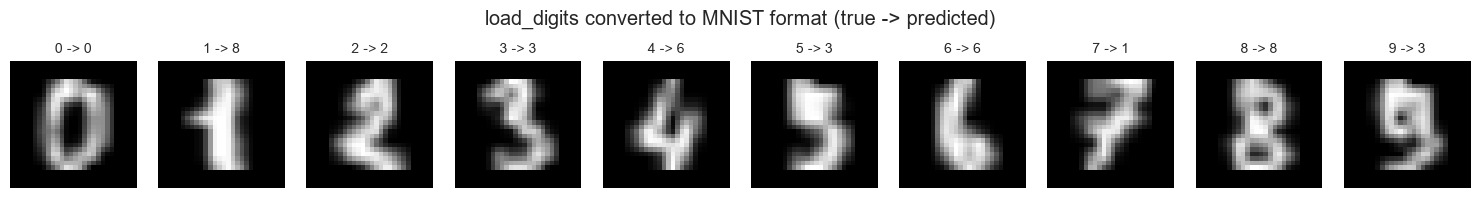

In [40]:
#Truly separate data - Scikit-learn's digits (8x8 -> 28x28)
# MNIST digits sit in a 20x20 box centered in a 28x28 frame,
# so we upscale 8x8 -> 20x20 and add 4 pixels of padding.
def digits_to_mnist_format(img_8x8):
    big = zoom(img_8x8.reshape(8, 8), 20 / 8, order=1)
    big = np.clip(big, 0, 1)
    return np.pad(big, 4)                     # -> 28x28

X_ext = np.array([digits_to_mnist_format(img) for img in Xd])
print("External set shape:", X_ext.shape)

ext_results = add_fit_flag(predict_cluster(X_ext))
ext_results["true_digit"] = yd

print(f"External accuracy:      {(ext_results.predicted_digit == ext_results.true_digit).mean():.1%}")
print(f"External good fit:      {ext_results.good_fit.mean():.1%}")
print(f"External mean distance: {ext_results.distance.mean():.3f}")

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for d in range(10):
    i = np.where(yd == d)[0][0]
    axes[d].imshow(X_ext[i], cmap="gray")
    axes[d].set_title(f"{d} -> {ext_results.predicted_digit[i]}", fontsize=10)
    axes[d].axis("off")
plt.suptitle("load_digits converted to MNIST format (true -> predicted)")
plt.tight_layout()
plt.savefig("external_predictions.png", dpi=120)
plt.show()

,noise_sigma,same_cluster_as_clean_%,accuracy_%,good_fit_%
0,0.0,100.0,59.4,95.2
1,0.1,97.2,60.0,96.9
2,0.2,94.2,60.8,93.8
3,0.3,91.1,61.1,67.4
4,0.5,83.9,60.2,0.0


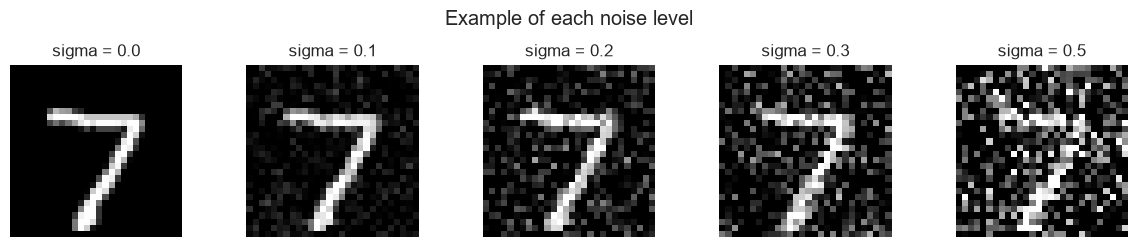

In [41]:
#Robustness - how do assignments hold up with noise?
noise_rows = []
for sigma in [0.0, 0.1, 0.2, 0.3, 0.5]:
    noisy = np.clip(X_test + rng.normal(0, sigma, X_test.shape), 0, 1).astype(np.float32)
    res = add_fit_flag(predict_cluster(noisy))
    noise_rows.append({
        "noise_sigma": sigma,
        "same_cluster_as_clean_%": (res.cluster.values == test_clusters).mean() * 100,
        "accuracy_%": (res.predicted_digit.values == y_test).mean() * 100,
        "good_fit_%": res.good_fit.mean() * 100,
    })
noise_df = pd.DataFrame(noise_rows).round(1)
display(noise_df)

fig, axes = plt.subplots(1, 5, figsize=(12, 2.5))
for ax, sigma in zip(axes, noise_df.noise_sigma):
    noisy_img = np.clip(X_test[0] + rng.normal(0, sigma, 784), 0, 1)
    ax.imshow(noisy_img.reshape(28, 28), cmap="gray")
    ax.set_title(f"sigma = {sigma}")
    ax.axis("off")
plt.suptitle("Example of each noise level")
plt.tight_layout()
plt.savefig("noise_levels.png", dpi=120)
plt.show()


In [42]:
#Validation summary
def summarize(name, res, true):
    return {"dataset": name,
            "images": len(res),
            "accuracy_%": round((res.predicted_digit.values == true).mean() * 100, 1),
            "good_fit_%": round(res.good_fit.mean() * 100, 1),
            "mean_distance": round(res.distance.mean(), 3),
            "mean_margin": round(res.margin.mean(), 3)}

train_res = add_fit_flag(predict_cluster(X_train))
summary = pd.DataFrame([
    summarize("Train (reference)", train_res, y_train),
    summarize("Test (unseen MNIST)", test_results, y_test),
    summarize("load_digits (external)", ext_results, yd),
])
display(summary)

,dataset,images,accuracy_%,good_fit_%,mean_distance,mean_margin
0,Train (reference),60000,59.1,95.0,6.161,0.145
1,Test (unseen MNIST),10000,59.4,95.2,6.163,0.144
2,load_digits (external),1797,33.6,100.0,5.028,0.121


In [48]:
#Predict your own handwritten digit image
def to_mnist_format(path):
    """Load an image file and convert it to MNIST style (28x28, white digit on black)."""
    img = Image.open(path).convert("L")                 # grayscale
    arr = np.array(img, dtype=np.float32)

    # 1. MNIST is white ink on black -> invert if background is light
    if arr.mean() > 127:
        arr = 255 - arr

    # 2. Remove faint background noise
    arr[arr < 50] = 0
    assert arr.max() > 0, "No digit found - image is blank after cleaning"

    # 3. Crop to the digit's bounding box
    rows = np.where(arr.max(axis=1) > 0)[0]
    cols = np.where(arr.max(axis=0) > 0)[0]
    arr = arr[rows[0]:rows[-1] + 1, cols[0]:cols[-1] + 1]

    # 4. Resize so the longest side is 20 pixels (keeps aspect ratio)
    h, w = arr.shape
    scale = 20 / max(h, w)
    new_w, new_h = max(1, round(w * scale)), max(1, round(h * scale))
    arr = np.array(Image.fromarray(arr.astype(np.uint8)).resize((new_w, new_h),
                                                                Image.LANCZOS),
                   dtype=np.float32)

    # 5. Paste into a 28x28 black canvas
    canvas = np.zeros((28, 28), dtype=np.float32)
    top, left = (28 - new_h) // 2, (28 - new_w) // 2
    canvas[top:top + new_h, left:left + new_w] = arr

    # 6. Center by center of mass (same as original MNIST)
    cy, cx = center_of_mass(canvas)
    canvas = shift(canvas, (14 - cy, 14 - cx), order=1)

    return np.clip(canvas, 0, 255)


def predict_from_file(path):
    original = np.array(Image.open(path).convert("L"))
    arr = to_mnist_format(path)
    result = add_fit_flag(predict_cluster(arr))
    r = result.iloc[0]

    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    axes[0].imshow(original, cmap="gray")
    axes[0].set_title("Original file")
    axes[1].imshow(arr, cmap="gray")
    axes[1].set_title("After MNIST preprocessing")
    axes[2].imshow(kmeans.cluster_centers_[r.cluster].reshape(28, 28), cmap="gray")
    axes[2].set_title(f"Assigned centroid (C{r.cluster})")
    for ax in axes:
        ax.axis("off")
    fit_text = "good fit" if r.good_fit else "poor fit"
    plt.suptitle(f"Predicted digit: {r.predicted_digit} | margin {r.margin:.2f} | {fit_text}")
    plt.tight_layout()
    plt.show()
    return result

In [49]:
#Create a test image file (if you don't have one yet)
# Saves a test image as dark ink on white paper, like a real scan,
# so the function has to do the full preprocessing.
sample_i = 0
paper_style = 255 - (X_test[sample_i].reshape(28, 28) * 255)
big = Image.fromarray(paper_style.astype(np.uint8)).resize((200, 200), Image.NEAREST)
big.save("my_digit.png")
print("Saved my_digit.png | true digit:", y_test[sample_i])

Saved my_digit.png | true digit: 7


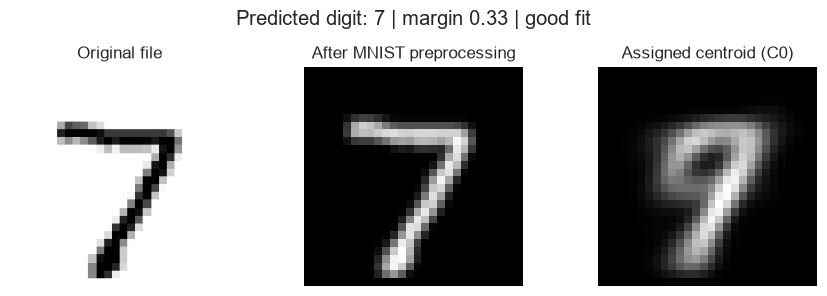

,cluster,predicted_digit,distance,margin,runner_up_cluster,threshold,good_fit
0,0,7,4.036,0.328,5,7.385,True


In [50]:
#Run the prediction
result = predict_from_file("my_digit.png")
display(result)

Part 4. Dimensionality Reduction and Visualization
1. Use PCA and t-SNE to reduce the dimensionality of the dataset for visualization purposes.
2. Visualize the clusters in two-dimensional space to assess the effectiveness of the clustering process and explore the relationships between different clusters.

In [52]:
# Readable cluster names, e.g. "C3 (8)" = cluster 3, mostly digit 8
cluster_names = {c: f"C{c} ({cluster_to_digit[c]})" for c in range(K)}


In [53]:
# Sample for visualization
# t-SNE is slow on large data, so we use 5,000 training images.
viz_idx = rng.choice(len(X_train), 5000, replace=False)
X_viz = X_train[viz_idx]
y_viz = y_train[viz_idx]
c_viz = train_clusters[viz_idx]

assert len(X_viz) == len(y_viz) == len(c_viz), "Sample arrays are misaligned"
print("Visualization sample:", X_viz.shape)

Visualization sample: (5000, 784)


In [54]:
# PCA (2D for plotting, 50D as t-SNE input)
pca_viz = PCA(n_components=2, random_state=42).fit(X_train)
pca_2d = pca_viz.transform(X_viz)
pca_centroids = pca_viz.transform(kmeans.cluster_centers_)

print(f"PC1 explains {pca_viz.explained_variance_ratio_[0]:.1%} of variance")
print(f"PC2 explains {pca_viz.explained_variance_ratio_[1]:.1%} of variance")
print(f"2D PCA keeps {pca_viz.explained_variance_ratio_.sum():.1%} in total")

# Standard practice: reduce to ~50 dims with PCA before t-SNE
# (removes noise and makes t-SNE much faster)
pca50 = PCA(n_components=50, random_state=42).fit(X_train)
X_viz_50 = pca50.transform(X_viz)
print(f"50D PCA keeps {pca50.explained_variance_ratio_.sum():.1%} of variance")


PC1 explains 9.7% of variance
PC2 explains 7.1% of variance
2D PCA keeps 16.8% in total
50D PCA keeps 82.5% of variance


In [55]:
#t-SNE (takes ~30-90 seconds)
start = time.time()
tsne = TSNE(n_components=2, perplexity=30, init="pca",
            learning_rate="auto", random_state=42)
tsne_2d = tsne.fit_transform(X_viz_50)
print(f"t-SNE finished in {time.time() - start:.1f}s | shape: {tsne_2d.shape}")


t-SNE finished in 21.9s | shape: (5000, 2)


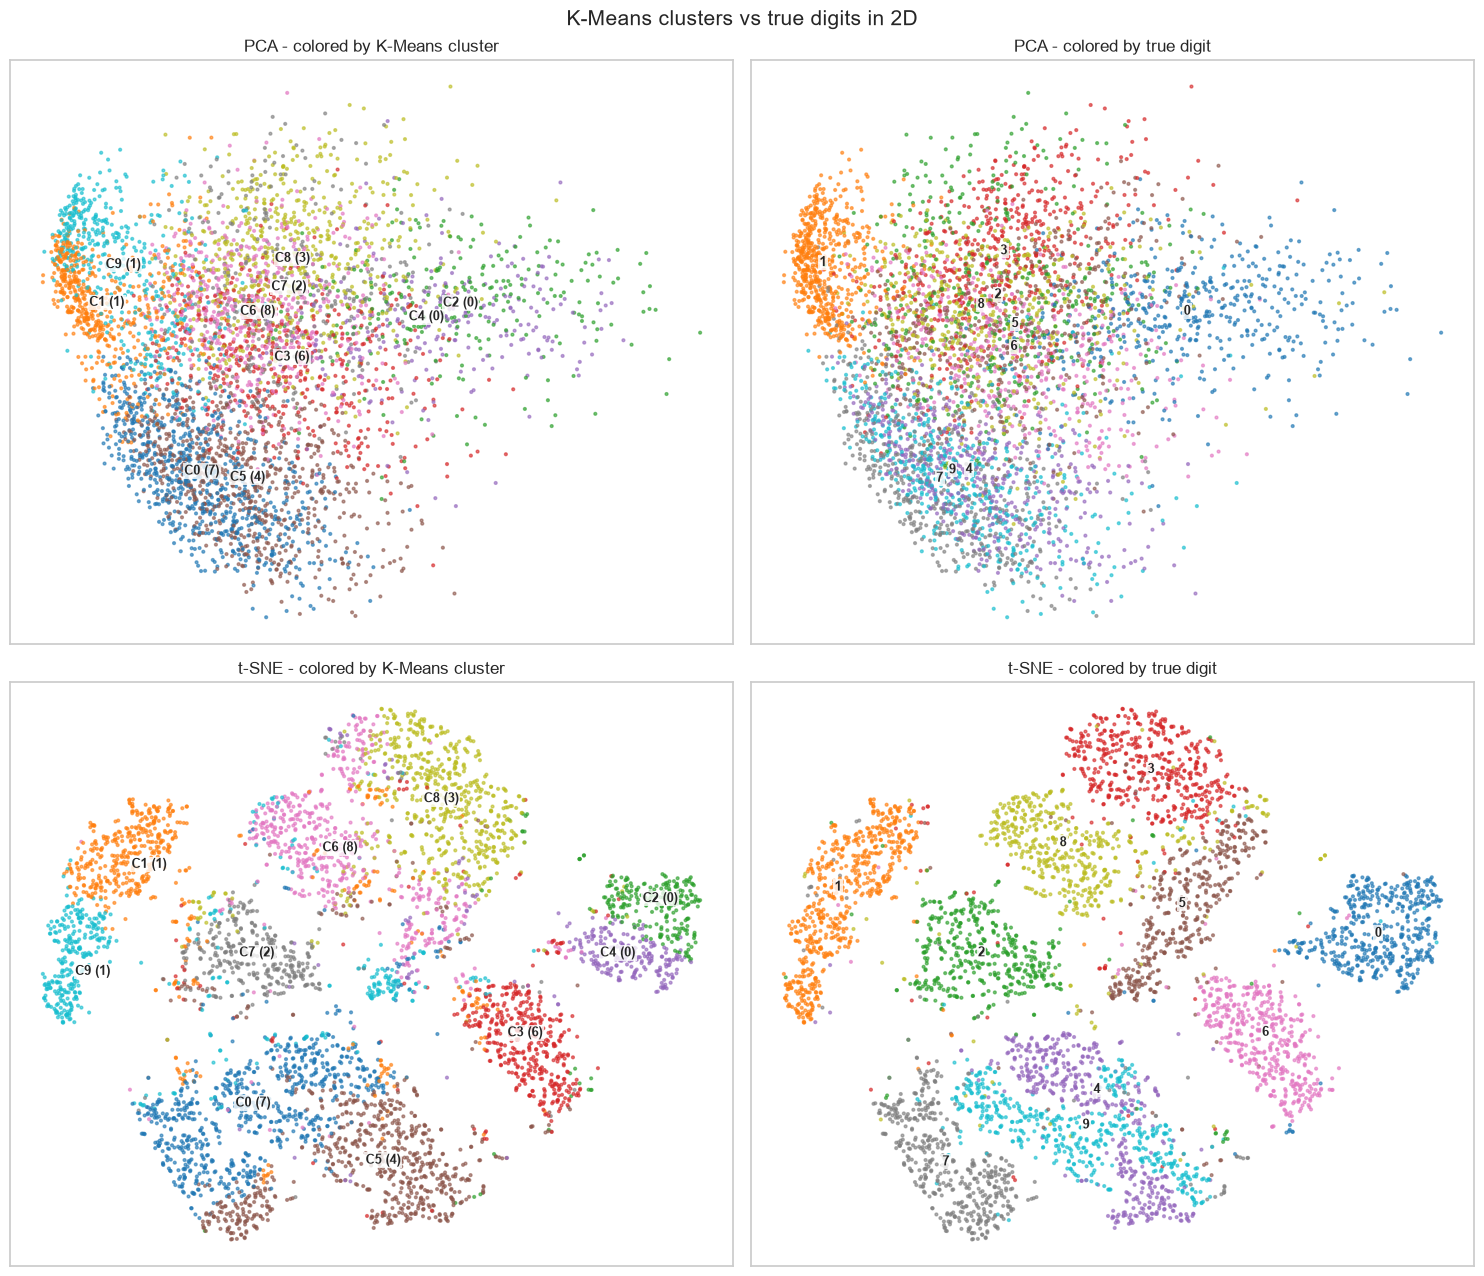

In [56]:
#PCA vs t-SNE, colored by cluster and by true digit
def plot_embedding(ax, emb, labels, title, names=None, centers=None):
    ax.scatter(emb[:, 0], emb[:, 1], c=labels, cmap="tab10",
               s=4, alpha=0.6, vmin=-0.5, vmax=9.5)
    for g in np.unique(labels):
        x0, y0 = centers[g] if centers is not None else np.median(emb[labels == g], axis=0)
        text = names[g] if names else str(g)
        ax.text(x0, y0, text, fontsize=9, fontweight="bold", ha="center",
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=1))
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

fig, axes = plt.subplots(2, 2, figsize=(15, 13))
plot_embedding(axes[0, 0], pca_2d, c_viz, "PCA - colored by K-Means cluster",
               names=cluster_names, centers=pca_centroids)
plot_embedding(axes[0, 1], pca_2d, y_viz, "PCA - colored by true digit")
plot_embedding(axes[1, 0], tsne_2d, c_viz, "t-SNE - colored by K-Means cluster",
               names=cluster_names)
plot_embedding(axes[1, 1], tsne_2d, y_viz, "t-SNE - colored by true digit")
plt.suptitle("K-Means clusters vs true digits in 2D", fontsize=15)
plt.tight_layout()
plt.savefig("pca_tsne_clusters.png", dpi=120)
plt.show()



Points whose cluster's majority digit != true digit: 41.0%


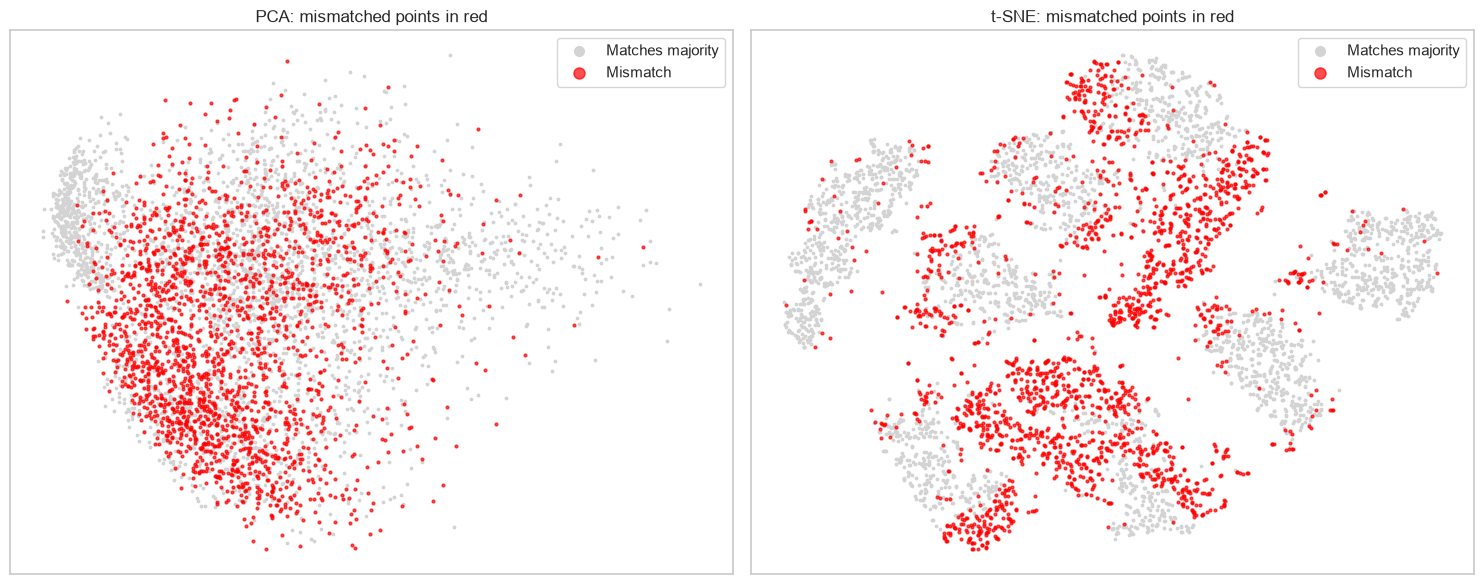

cluster_says,0,1,2,3,4,6,7,8
true_digit,,,,,,,,
0,0,3,0,7,6,18,1,9
1,0,0,0,0,0,2,1,1
2,4,67,0,27,23,15,3,13
3,11,44,18,0,13,7,1,92
4,1,31,0,0,0,8,187,1
5,33,74,2,141,32,8,27,124
6,13,41,4,3,6,0,0,7
7,5,49,3,1,148,0,0,1
8,8,62,4,79,21,3,19,0


In [57]:
#Where does K-Means get it wrong?
mapped_viz = np.array([cluster_to_digit[c] for c in c_viz])
wrong = mapped_viz != y_viz
print(f"Points whose cluster's majority digit != true digit: {wrong.mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, emb, name in zip(axes, [pca_2d, tsne_2d], ["PCA", "t-SNE"]):
    ax.scatter(emb[~wrong, 0], emb[~wrong, 1], c="lightgrey", s=3, label="Matches majority")
    ax.scatter(emb[wrong, 0], emb[wrong, 1], c="red", s=4, alpha=0.7, label="Mismatch")
    ax.set_title(f"{name}: mismatched points in red")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(markerscale=4)
plt.tight_layout()
plt.savefig("mismatch_map.png", dpi=120)
plt.show()

# Which true digits cause most mismatches?
mismatch_table = pd.crosstab(pd.Series(y_viz[wrong], name="true_digit"),
                             pd.Series(mapped_viz[wrong], name="cluster_says"))
display(mismatch_table)



In [58]:
#Measure how well each 2D view preserves the structure
# Trustworthiness: are neighbors in 2D also neighbors in 784D? (1.0 = perfect)
# Silhouette: how separated the clusters look (-1 to 1, higher = better)
effectiveness = pd.DataFrame({
    "space": ["Original (784D)", "PCA (2D)", "t-SNE (2D)"],
    "silhouette_by_cluster": [silhouette_score(X_viz, c_viz),
                              silhouette_score(pca_2d, c_viz),
                              silhouette_score(tsne_2d, c_viz)],
    "silhouette_by_true_digit": [silhouette_score(X_viz, y_viz),
                                 silhouette_score(pca_2d, y_viz),
                                 silhouette_score(tsne_2d, y_viz)],
    "trustworthiness": [1.0,
                        trustworthiness(X_viz, pca_2d, n_neighbors=10),
                        trustworthiness(X_viz, tsne_2d, n_neighbors=10)],
}).round(3)
display(effectiveness)


,space,silhouette_by_cluster,silhouette_by_true_digit,trustworthiness
0,Original (784D),0.059,0.046,1.000
1,PCA (2D),-0.019,0.036,0.739
2,t-SNE (2D),0.185,0.316,0.982


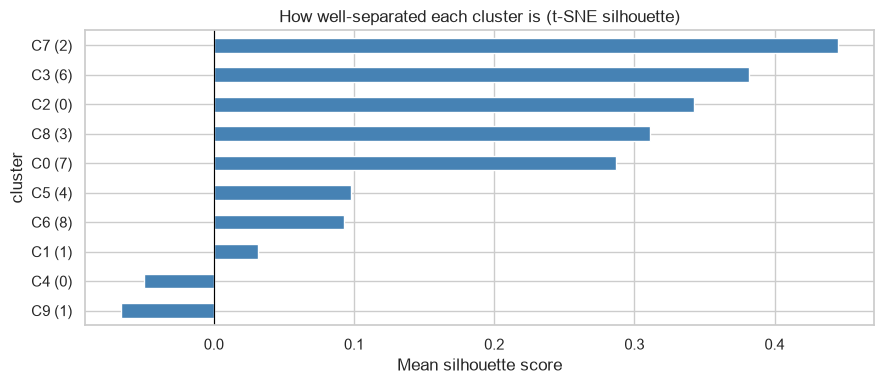

In [59]:
# Per-cluster separation in t-SNE space
sil_each = silhouette_samples(tsne_2d, c_viz)
sil_by_cluster = (pd.DataFrame({"cluster": c_viz, "silhouette": sil_each})
                  .groupby("cluster")["silhouette"].mean()
                  .rename(index=cluster_names).sort_values())

plt.figure(figsize=(9, 4))
sil_by_cluster.plot(kind="barh", color="steelblue")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("How well-separated each cluster is (t-SNE silhouette)")
plt.xlabel("Mean silhouette score")
plt.tight_layout()
plt.savefig("silhouette_per_cluster.png", dpi=120)
plt.show()


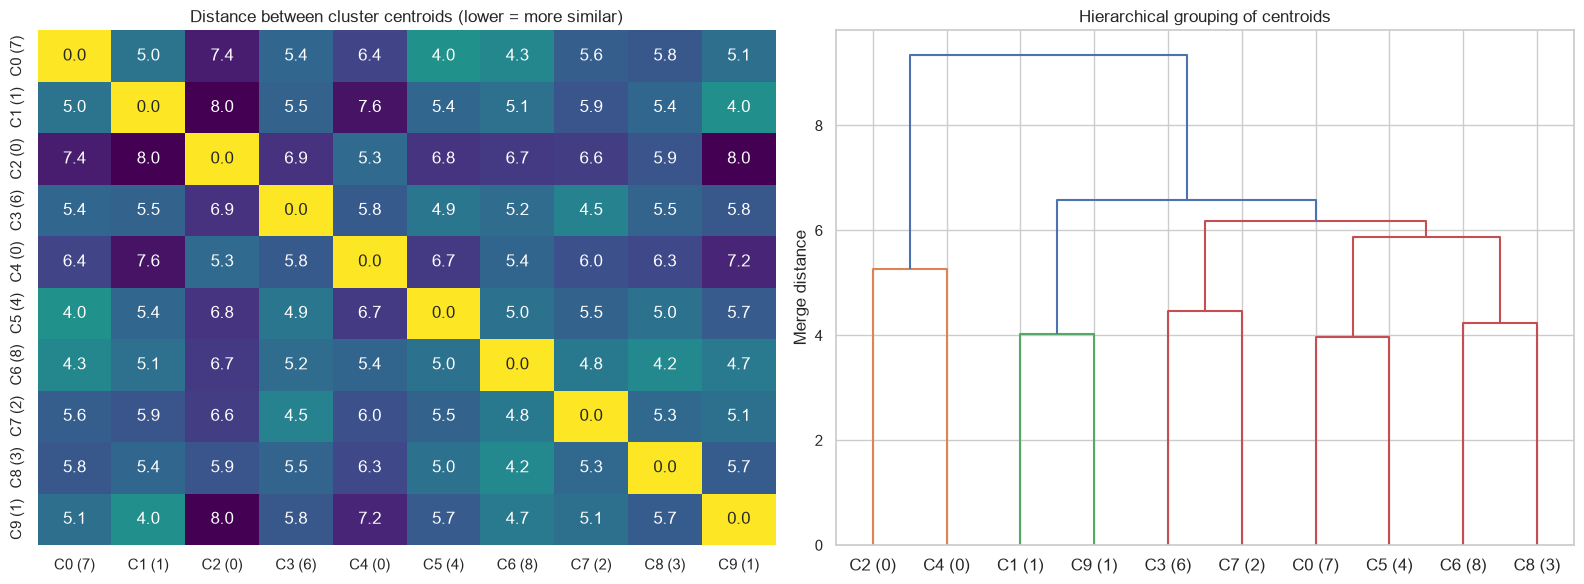

,cluster,closest_cluster,distance
0,C0 (7),C5 (4),3.98
5,C5 (4),C0 (7),3.98
1,C1 (1),C9 (1),4.02
9,C9 (1),C1 (1),4.02
8,C8 (3),C6 (8),4.24
6,C6 (8),C8 (3),4.24
7,C7 (2),C3 (6),4.46
3,C3 (6),C7 (2),4.46
4,C4 (0),C2 (0),5.27
2,C2 (0),C4 (0),5.27


In [60]:
#Relationships between clusters - centroid distances
centroids = kmeans.cluster_centers_
D = cdist(centroids, centroids)
labels_list = [cluster_names[c] for c in range(K)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(pd.DataFrame(D, index=labels_list, columns=labels_list),
            annot=True, fmt=".1f", cmap="viridis_r", ax=axes[0], cbar=False)
axes[0].set_title("Distance between cluster centroids (lower = more similar)")

dendrogram(linkage(centroids, method="ward"), labels=labels_list, ax=axes[1])
axes[1].set_title("Hierarchical grouping of centroids")
axes[1].set_ylabel("Merge distance")
plt.tight_layout()
plt.savefig("centroid_relationships.png", dpi=120)
plt.show()

# Closest neighbor for each cluster
D_no_self = D + np.eye(K) * D.max()
nearest = pd.DataFrame({
    "cluster": labels_list,
    "closest_cluster": [cluster_names[j] for j in D_no_self.argmin(axis=1)],
    "distance": D_no_self.min(axis=1).round(2),
}).sort_values("distance")
display(nearest)


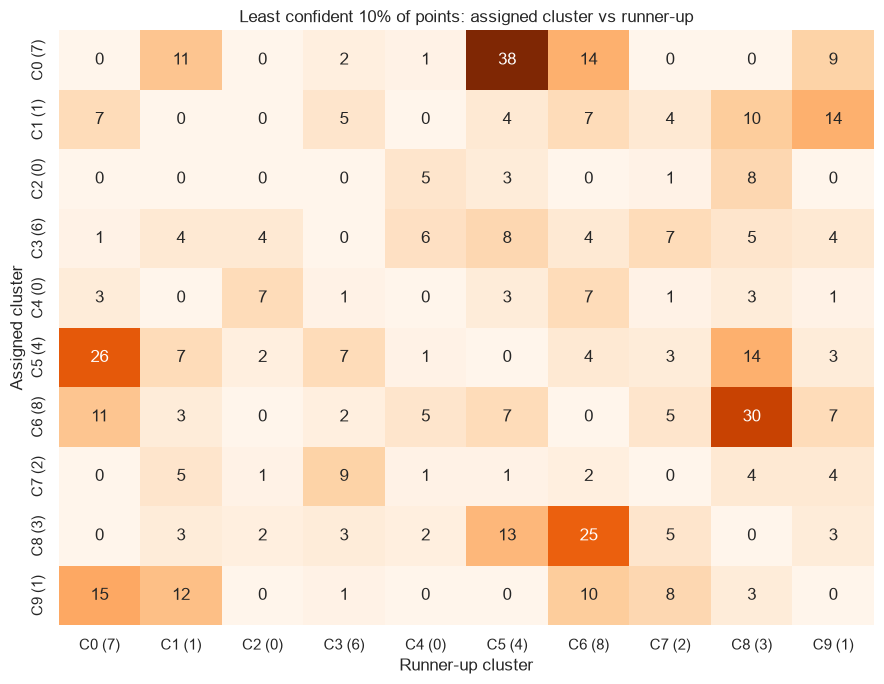

In [61]:
# Boundary analysis - which clusters compete for points?
viz_pred = predict_cluster(X_viz)
boundary = viz_pred[viz_pred.margin < viz_pred.margin.quantile(0.10)]   # least confident 10%

competition = pd.crosstab(boundary.cluster.map(cluster_names),
                          boundary.runner_up_cluster.map(cluster_names))
plt.figure(figsize=(9, 7))
sns.heatmap(competition, annot=True, fmt="d", cmap="Oranges", cbar=False)
plt.title("Least confident 10% of points: assigned cluster vs runner-up")
plt.xlabel("Runner-up cluster")
plt.ylabel("Assigned cluster")
plt.tight_layout()
plt.savefig("cluster_competition.png", dpi=120)
plt.show()


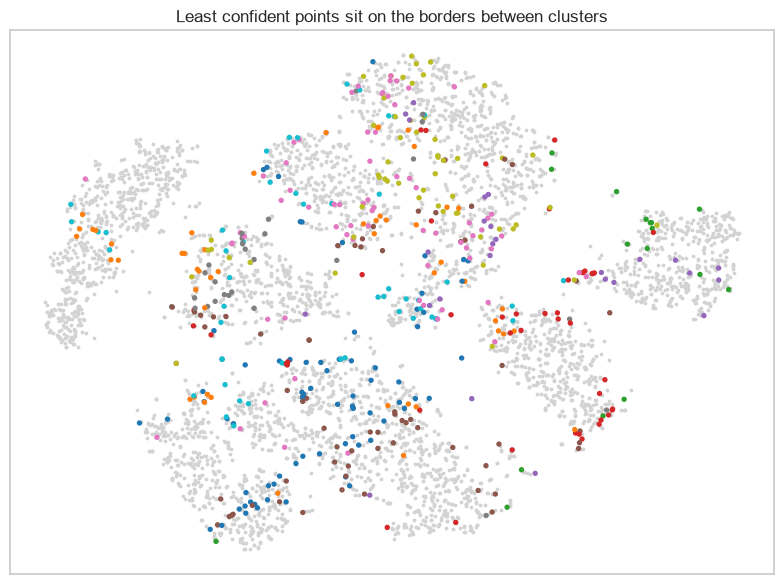

In [62]:
# Show those uncertain points on the t-SNE map
plt.figure(figsize=(8, 6))
plt.scatter(tsne_2d[:, 0], tsne_2d[:, 1], c="lightgrey", s=3)
b = boundary.index.values
plt.scatter(tsne_2d[b, 0], tsne_2d[b, 1], c=c_viz[b], cmap="tab10",
            s=8, vmin=-0.5, vmax=9.5)
plt.title("Least confident points sit on the borders between clusters")
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig("boundary_points_tsne.png", dpi=120)
plt.show()


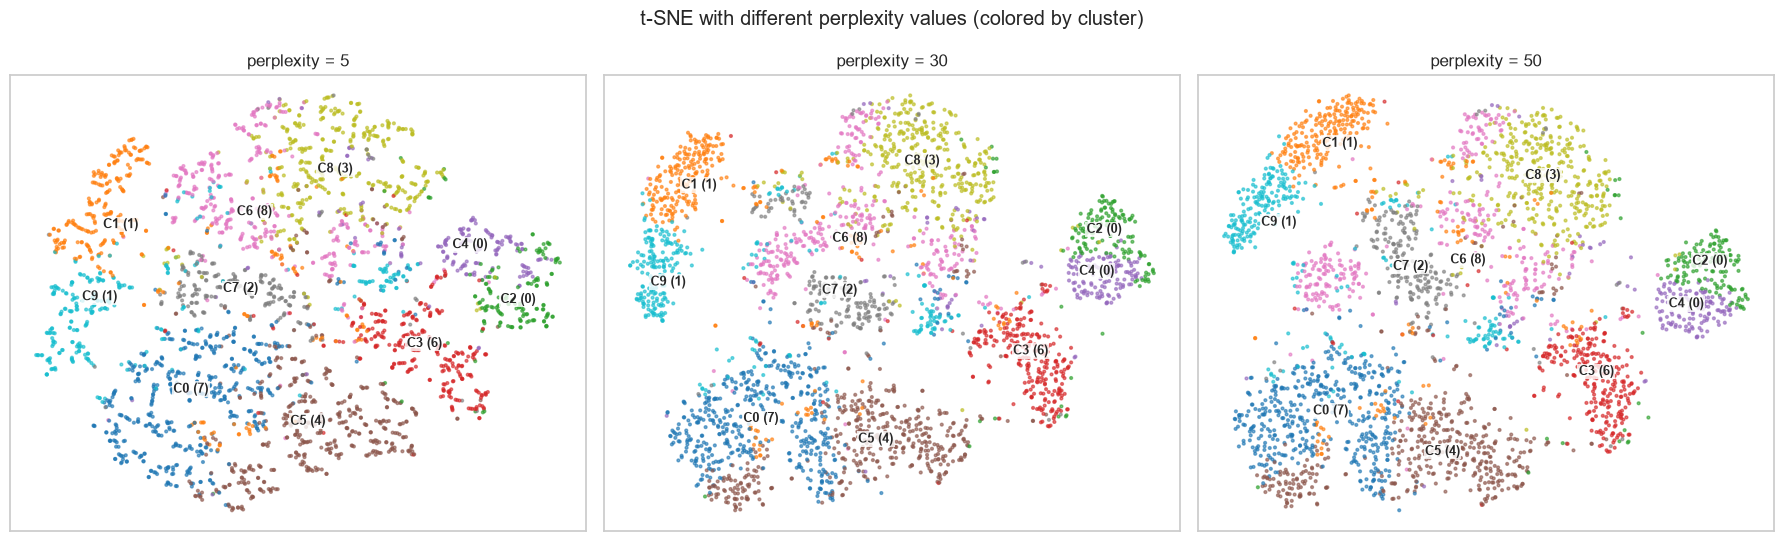

In [63]:
#t-SNE perplexity comparison (takes ~1-2 minutes)
# Perplexity controls how many neighbors t-SNE considers.
# Low = focuses on local detail, high = more global structure.
sub = np.arange(3000)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, perp in zip(axes, [5, 30, 50]):
    emb = TSNE(n_components=2, perplexity=perp, init="pca",
               learning_rate="auto", random_state=42).fit_transform(X_viz_50[sub])
    plot_embedding(ax, emb, c_viz[sub], f"perplexity = {perp}", names=cluster_names)
plt.suptitle("t-SNE with different perplexity values (colored by cluster)")
plt.tight_layout()
plt.savefig("tsne_perplexity.png", dpi=120)
plt.show()

In [64]:
#Does clustering improve in reduced space?
def majority_accuracy(clusters, true):
    ct_ = pd.crosstab(clusters, true)
    mapping = ct_.idxmax(axis=1).to_dict()
    return (pd.Series(clusters).map(mapping).values == true).mean()

rows = []
for name, data in [("Pixels (784D)", X_viz), ("PCA (50D)", X_viz_50),
                   ("PCA (2D)", pca_2d), ("t-SNE (2D)", tsne_2d)]:
    labels_ = KMeans(n_clusters=10, n_init=10, random_state=42).fit_predict(data)
    rows.append({"space": name,
                 "accuracy_%": round(majority_accuracy(labels_, y_viz) * 100, 1),
                 "ARI": round(adjusted_rand_score(y_viz, labels_), 3),
                 "NMI": round(normalized_mutual_info_score(y_viz, labels_), 3)})
display(pd.DataFrame(rows))


,space,accuracy_%,ARI,NMI
0,Pixels (784D),58.0,0.364,0.494
1,PCA (50D),55.7,0.341,0.478
2,PCA (2D),41.5,0.247,0.367
3,t-SNE (2D),81.9,0.713,0.767


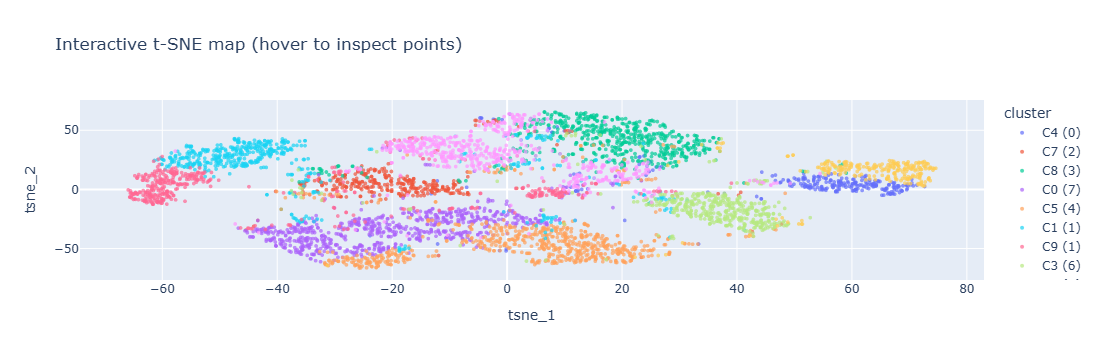

In [66]:
#(Optional): Interactive t-SNE map with Plotly
import plotly.express as px

plot_df_tsne = pd.DataFrame({
    "tsne_1": tsne_2d[:, 0], "tsne_2": tsne_2d[:, 1],
    "cluster": [cluster_names[c] for c in c_viz],
    "true_digit": y_viz.astype(str),
    "margin": viz_pred.margin.values,
})
fig = px.scatter(plot_df_tsne, x="tsne_1", y="tsne_2", color="cluster",
                 hover_data=["true_digit", "margin"], opacity=0.7,
                 title="Interactive t-SNE map (hover to inspect points)")
fig.update_traces(marker=dict(size=4))
fig.show()

In [69]:
# Save results to CSV (for GitHub)
os.makedirs('results', exist_ok=True)
os.makedirs('models', exist_ok=True)
GITHUB_LIMIT_MB = 100

def to_frame(obj):
    """Convert lists, Series and arrays to a DataFrame so every table saves the same way."""
    if isinstance(obj, list):       
        return pd.DataFrame(obj)
    if isinstance(obj, pd.Series):
        return obj.to_frame()
    if isinstance(obj, np.ndarray):
        return pd.DataFrame(obj)
    return obj

def save_csv(obj, filename, index=True):
    path = os.path.join('results', filename)
    to_frame(obj).to_csv(path, index=index)
    size_mb = os.path.getsize(path) / 1e6
    print(f"saved {path:<45} {size_mb:>8.2f} MB")
    return size_mb

# 1. Results tables (small, safe for GitHub)
tables = {
    # Part 1 - Data preparation & EDA
    'class_distribution.csv':        'dist',
    'mnist_vs_load_digits.csv':      'comparison',
    # Part 2 - Clustering
    'elbow_silhouette.csv':          'elbow_df',
    'cluster_vs_digit_crosstab.csv': 'ct',
    'cluster_profile.csv':           'profile',
    # Part 3 - Evaluation & prediction
    'fit_thresholds.csv':            'fit_threshold',
    'per_cluster_fit.csv':           'per_cluster',
    'per_digit_accuracy.csv':        'per_digit',
    'noise_robustness.csv':          'noise_df',
    'validation_summary.csv':        'summary',
    # Part 4 - Dimensionality reduction
    'embedding_effectiveness.csv':   'effectiveness',
    'nearest_clusters.csv':          'nearest',
    'mismatch_table.csv':            'mismatch_table',
    'cluster_competition.csv':       'competition',
    'reduced_space_clustering.csv':  'rows',
}
for filename, var in tables.items():
    if var in globals():
        save_csv(globals()[var], filename)
    else:
        print(f"skipped {filename} ('{var}' not found, run its cell first)")

# Confusion matrix (numpy array -> labeled table)
if 'cm' in globals():
    cm_df = pd.DataFrame(cm, index=[f"true_{d}" for d in range(10)],
                         columns=[f"pred_{d}" for d in range(10)])
    save_csv(cm_df, 'test_confusion_matrix.csv')


# 2. Prediction outputs (row-level, still small)
train_assign = pd.DataFrame({
    'image_index': np.arange(len(y_train)),
    'true_digit': y_train,
    'cluster': train_clusters,
    'predicted_digit': pd.Series(train_clusters).map(cluster_to_digit).values,
    'distance': train_dist.round(4),
})
save_csv(train_assign, 'train_cluster_assignments.csv', index=False)

test_out = test_results.copy()
test_out.insert(0, 'image_index', np.arange(60000, 60000 + len(test_out)))
save_csv(test_out, 'test_predictions.csv', index=False)

save_csv(ext_results, 'external_load_digits_predictions.csv', index=False)


# 3. Centroids and 2D coordinates (for rebuilding the charts in Power BI or Tableau)
centroids_df = pd.DataFrame(kmeans.cluster_centers_.round(5),
                            columns=[f"px_{i}" for i in range(784)])
centroids_df.insert(0, 'majority_digit', [cluster_to_digit[c] for c in range(K)])
centroids_df.index.name = 'cluster'
save_csv(centroids_df, 'cluster_centroids.csv')

embeddings = pd.DataFrame({
    'image_index': viz_idx,
    'true_digit': y_viz,
    'cluster': c_viz,
    'cluster_name': [cluster_names[c] for c in c_viz],
    'pca_1': pca_2d[:, 0].round(4), 'pca_2': pca_2d[:, 1].round(4),
    'tsne_1': tsne_2d[:, 0].round(4), 'tsne_2': tsne_2d[:, 1].round(4),
    'margin': viz_pred.margin.values,
})
save_csv(embeddings, 'embeddings_2d_sample_5k.csv', index=False)


# 4. Size check against the GitHub limit
print("\nFiles in results/:")
total_mb = 0
for f in sorted(os.listdir('results')):
    mb = os.path.getsize(os.path.join('results', f)) / 1e6
    total_mb += mb
    flag = "  <-- OVER GITHUB LIMIT" if mb > GITHUB_LIMIT_MB else ""
    print(f"   {f:<42} {mb:>8.2f} MB{flag}")
print(f"\nTotal: {total_mb:.2f} MB")

too_big = [f for f in os.listdir('results')
           if os.path.getsize(os.path.join('results', f)) / 1e6 > GITHUB_LIMIT_MB]
assert not too_big, f"Files over {GITHUB_LIMIT_MB} MB: {too_big}"
print("All files are within GitHub's limit.")

# Save the trained model (so predictions work without retraining)
model_path = os.path.join('models', 'kmeans_k10.joblib')
joblib.dump(kmeans, model_path)

model_info = {
    'n_clusters': K,
    'cluster_to_digit': {int(k): int(v) for k, v in cluster_to_digit.items()},
    'fit_threshold_95pct': {int(k): float(v) for k, v in fit_threshold.items()},
    'inertia': float(kmeans.inertia_),
    'train_images': int(len(X_train)),
    'preprocessing': 'pixels / 255, flattened to 784 values',
    'saved_on': pd.Timestamp.now(),
}
with open(os.path.join('models', 'model_info.json'), 'w') as f:
    json.dump(model_info, f, indent=2, default=str)   # default=str handles Timestamp

print(f"saved {model_path} ({os.path.getsize(model_path) / 1e6:.2f} MB)")
print("saved models/model_info.json")

# Reload test: make sure the saved model gives the same predictions
reloaded = joblib.load(model_path)
assert (reloaded.predict(X_test) == test_clusters).all(), "Reloaded model predicts differently"
print("Reloaded model matches the original.")

saved results\class_distribution.csv                    0.00 MB
saved results\mnist_vs_load_digits.csv                  0.00 MB
saved results\elbow_silhouette.csv                      0.00 MB
saved results\cluster_vs_digit_crosstab.csv             0.00 MB
saved results\cluster_profile.csv                       0.00 MB
saved results\fit_thresholds.csv                        0.00 MB
saved results\per_cluster_fit.csv                       0.00 MB
saved results\per_digit_accuracy.csv                    0.00 MB
saved results\noise_robustness.csv                      0.00 MB
saved results\validation_summary.csv                    0.00 MB
saved results\embedding_effectiveness.csv               0.00 MB
saved results\nearest_clusters.csv                      0.00 MB
saved results\mismatch_table.csv                        0.00 MB
saved results\cluster_competition.csv                   0.00 MB
saved results\reduced_space_clustering.csv              0.00 MB
saved results\test_confusion_matrix.csv 